<a href="https://colab.research.google.com/github/PeterShiaush/ColabYolo26/blob/main/%E5%AD%B8%E7%94%9FTrainYolo26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 逐步執行以下:

1.   點擊上面的「**Open in Colab**」的連結
2.   再點擊上面  **複製到雲端硬碟**，成為**自己的colab 檔案**
3.   再**左上角** 修改檔名  : **訓練TrainYolo26.ipynb**
4.   右上角，輪圈(設定): 編輯器，**顯示行號**

---

## 上傳  Roboflow下載的資料集壓縮擋



*   Roboflow 下載的資料集壓縮擋(zip)
*   上傳或拖曳，到左側



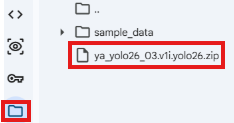






## **修正以下程式碼**


*   下面程式碼會將下載的資料集，
*   解壓縮到/content裡面



In [ ]:
# 導入 `os` 模組，用於操作檔案和資料夾，例如建立資料夾、檢查檔案是否存在等。
import ???
# 導入 `zipfile` 模組，用於處理壓縮檔案（.zip），例如解壓縮資料集。
import ???

#---------------------------------------------------------------------------------------------------------------------------------------
# --- 步驟 A：專案資料夾設定與資料解壓縮 ---
# 這個步驟會為你的 AI 專案建立一個專屬的工作環境，並將從 Roboflow 下載的資料集解壓縮到裡面。

project_name = ??? # 設定專案名稱 ??? -> "roboflow_dataset"。這個名稱將決定你的專案資料夾名稱。
target_path = f"/content/{project_name}" # 這是你的專案資料夾的完整路徑，位於 Colab 的 `/content` 下。

# 1. 建立專案資料夾
???.makedirs(target_path, ???=True) # 使用 `os` 模組建立資料夾。`exist_ok=True` 代表如果資料夾已存在，就不會報錯。

# 2. 自動尋找並解壓上傳的 zip 檔
# **重要提示：請務必將從 Roboflow 下載的資料集壓縮檔（例如 `dataset.zip`）拖曳到 Colab 左側的檔案區！**
# 這行程式碼會使用 `os` 模組，在 `/content` 資料夾中尋找所有以 `.zip` 結尾的檔案。
# 右側程式，也是對的，但不易理解  zip_files = [f for f in os.listdir('/content') if f.endswith(".zip")]
# 以下程式碼，容易理解，但冗長
zip_files = [] # 初始化一個空列表，用來存放找到的 .zip 檔案名稱。
for file in ??.listdir('/content'): # 遍歷 `/content` 資料夾中的每一個檔案或資料夾。
    if file.endswith(???): # 檢查檔案名稱是否以 ".zip" 結尾。
        zip_files.append(file) # 如果是 .zip 檔案，就將其加入 `zip_files` 列表。



if ???: # 判斷 `zip_files` 列表中是否有找到任何 `.zip` 檔案。
    with ???.ZipFile(f'/content/{zip_files[0]}', 'r') as zip_ref: # 使用 `zipfile` 模組打開找到的第一個 `.zip` 檔案。
        zip_ref.extractall(???) # 將 `.zip` 檔案的內容，解壓縮到 `target_path` 指定的資料夾中。
    print(f"✅ 解壓縮完成！資料已放在: {target_path}")
else: # 如果 `zip_files` 列表是空的，代表沒有找到 `.zip` 檔案。
    print("❌ 找不到 zip 檔案，請確認已將資料集壓縮檔拖曳到 Colab 檔案區。")
#----------------------------------------------------------------------------------------------------------------------------------------
# --- 步驟 B：檢查環境設定 ---
# 這個步驟是確認 AI 訓練所需的關鍵設定檔 `data.yaml` 是否存在於正確的位置。`data.yaml` 包含了資料集的路徑和類別資訊。

test_dir = target_path # 我們的測試目標資料夾就是上面建立的專案資料夾。
print("-" * 30) # 印出一條分隔線，讓輸出訊息更清晰。
if ???.path.exists(os.path.join(test_dir, ???)): # 使用 `os` 模組檢查 `data.yaml` 是否存在於 `test_dir` 內。
    print("✅ 環境設定 OK！已偵測到 data.yaml") # 成功找到 `data.yaml`，表示環境設定正確，可以進行下一步。
    !pip install ??? -q # 這行程式碼會順便，安裝 `ultralytics`套件，這是訓練 YOLO模型的工具。`-q` 參數代表安靜安裝，不顯示詳細過程。
    print("✅ YOLO 驅動程式安裝完成！")
else: # 如果 `data.yaml` 不存在...
    print("❌ 測試失敗，找不到 data.yaml。請檢查你的 zip 檔是否正確解壓縮或資料夾名稱。") # 提示錯誤，需要檢查檔案或資料夾設置。

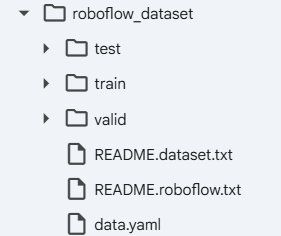

## AI 資料集名稱


1.   **Train** (訓練集),課本與習題。
2.   **Valid** (驗證集),考前模擬考,訓練時邊讀邊考。
3.   **Test** (測試集),正式期末考。

---

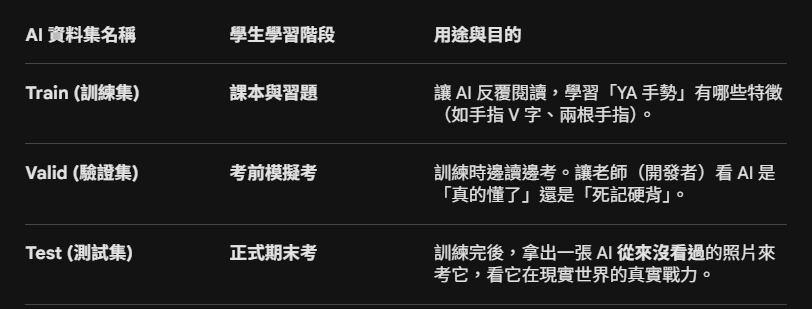

## 啟動  **T4 GPU**


*   將擁有 nvidia 獨立顯卡**T4 GPU**
*   ✅ **CUDA** is available! Using T4 GPU.
*   訓練的優勢是使用 ✅ **CUDA**



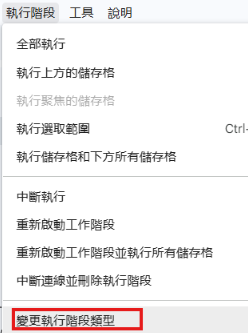

## 檢查 T4 GPU

測試是否有 ✅ **CUDA**?

In [ ]:
import torch

if torch.????.is_available(): # <-- 請填入 PyTorch 中檢查 CUDA 可用性的子模組名稱 (例如 'cuda')。
    print("✅ CUDA is available! Using T4 GPU.")
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
else:
    print("❌ CUDA is NOT available. Training will proceed on CPU.")
    print("請確保您已在 Colab 的 '執行階段' -> '變更執行階段類型' 中選擇了 'GPU'。")

## 重頭戲 **best.pt**

*   開始 **訓練 train** 出模型
*   模型: **best.pt**



In [ ]:
# 安裝 ultralytics， Python需要用到的 套件
!pip install ultralytics -q

#
from ultralytics import ??? # <-- 請填入 `ultralytics` 庫中用來建立和訓練模型的類別名稱。
import ??? # <-- 請填入 Python 內建的「作業系統」模組名稱。

# 1. 載入模型預訓練權重
# 我們選擇專用的 'yolo26n.pt'，這是專為 2026 專題優化的 Nano 版本
# 它的特點是：訓練極快、模型極小（幾 MB），非常適合跑在學生手機或筆電上
model = YOLO(???) # <-- 請填入你想使用的預訓練模型權重檔案名稱，例如 'yolo26n.pt'。

# --- 建立專案資料夾的資訊 ---
project_name = ??? # <-- 請為你的專案設定一個獨特的名稱，用引號包起來，例如 "roboflow_??????"。
target_path = f"/content/{project_name}"

# 2. 開始訓練
# 訓練過程會根據你的 data.yaml 設定，產出專屬於 YA 手勢的權重
results = model.train(
    data=f"{target_path}/??", # <-- 請填入你的資料集設定檔名稱，通常是 `data.yaml`。
    epochs=???,                       # <-- 請設定 AI 反覆學習的次數，例如 50 遍。
    imgsz=???,                       # <-- 請設定影像縮放的標準尺寸，例如 640。
    batch=???,                        # <-- 請設定一次處理的影像數量，例如 16。
    device=???,                        # <-- 請填入你想使用的訓練裝置，0 代表使用 GPU。
    name='???'              # <-- 請為這次訓練的結果設定一個儲存資料夾名稱，建議加上版本號，用引號包起來，例如 'ya_yolo26_v50'
)

print("\n" + "="*30)
print("🎉 訓練結束！YA_YOLO26 引擎已啟動！")

# 3. 找出產出的 best.pt 位置
# 注意：路徑中的資料夾名稱必須與上方 name 參數一致
best_model_path = 'runs/detect/???/weights/best.pt' # <-- 請填入你設定的訓練結果資料夾名稱，用引號包起來。

if os.path.exists(best_model_path):
    print(f"✅ 成功產出！這就是你的 AI 大腦：{best_model_path}")

    # 【課堂加分題】自動更名為專題名稱，方便辨識
    final_name = ??? # <-- 請設定最終模型的儲存路徑和檔案名稱，例如 "/content/ya_yolo26n_best.pt"。
    ???.rename(???, ???) # <-- 前面 ??? 請填入 `os` 模組的檔案重新命名函數；後面兩個 ??? 請分別填入 `best_model_path` 和 `final_name`。
    print(f"📦 已自動更名並移動至: {final_name}")
else:
    print("❌ 找不到 best.pt，請檢查左側 runs 資料夾路徑或訓練 log。")

### 方法一：用測試集照片進行「盲測」 (最直觀)
我們會從 AI 從未看過的 test 資料夾中抓一張照片出來，讓 ya_yolo26n_best.pt 進行辨識。

In [ ]:
from ultralytics import YOLO
import cv2
import os
from google.colab.patches import cv2_imshow # Colab 專用顯示工具

# 1. 載入你剛剛訓練好的最強大腦
model = YOLO('/content/????.pt')

# 2. 隨機選一張測試集照片 (路徑需對應你的 target_path)
test_img_path = f"{target_path}/test/????" # 修正路徑，期末考的 'test'的 "images"
all_test_imgs = os.listdir(test_img_path)
sample_img = os.path.join(test_img_path, all_test_imgs[??]) # 抓第2張

# 3. 進行推理 (Inference)
results = model.predict(source=sample_img, conf=0.4) # conf=0.4 代表信心度超過 50% 才顯示

# 4. 顯示結果
res_plotted = results[0].plot() # 將辨識結果畫在圖上
cv2_imshow(res_plotted)

### 方法二：查看「驗證統計圖表」 (專題報告必備)
YOLO 在訓練結束後會自動生成多張統計圖，存放在 runs/detect/????/ 中。這些圖表能用科學數據證明你的模型有多強。

1. 混淆矩陣 (Confusion Matrix)
這張圖告訴你 AI 有沒有把「背景」誤認成「YA」，或是漏掉沒認出來。

In [ ]:
from IPython.display import Image
Image(filename='runs/detect/???/confusion_matrix.png', width=600)

2. 訓練曲線 (Results)
這張圖包含了 Loss (損失函數) 與 mAP (平均精度)。

*   左邊的 Loss：曲線應該要一路向下（代表 AI 錯誤越來越少）。
*   右邊的 mAP：曲線應該要一路向上（代表 AI 越來越準）。




In [ ]:
from IPython.display import Image
Image(filename='runs/detect/???/results.png', width=800)